In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/used_cars.csv")

In [3]:
df.head()

,Unnamed: 0,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW


In [4]:
df.shape

(99187, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99187 entries, 0 to 99186
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    99187 non-null  int64  
 1   model         99187 non-null  str    
 2   year          99187 non-null  int64  
 3   price         99187 non-null  int64  
 4   transmission  99187 non-null  str    
 5   mileage       99187 non-null  int64  
 6   fuelType      99187 non-null  str    
 7   tax           99187 non-null  int64  
 8   mpg           99187 non-null  float64
 9   engineSize    99187 non-null  float64
 10  Make          99187 non-null  str    
dtypes: float64(2), int64(5), str(4)
memory usage: 8.3 MB


In [6]:
df.isnull().sum() / len(df) * 100

Unnamed: 0      0.0
model           0.0
year            0.0
price           0.0
transmission    0.0
mileage         0.0
fuelType        0.0
tax             0.0
mpg             0.0
engineSize      0.0
Make            0.0
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['Unnamed: 0'])
df.duplicated().sum()  

np.int64(1475)

In [9]:
df = df.drop_duplicates()
df.shape  

(97712, 10)

In [10]:
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,T-Roc,2019,25000,Automatic,13904,Diesel,145,49.6,2.0,VW
1,T-Roc,2019,26883,Automatic,4562,Diesel,145,49.6,2.0,VW
2,T-Roc,2019,20000,Manual,7414,Diesel,145,50.4,2.0,VW
3,T-Roc,2019,33492,Automatic,4825,Petrol,145,32.5,2.0,VW
4,T-Roc,2019,22900,Semi-Auto,6500,Petrol,150,39.8,1.5,VW
5,T-Roc,2020,31895,Manual,10,Petrol,145,42.2,1.5,VW
6,T-Roc,2020,27895,Manual,10,Petrol,145,42.2,1.5,VW
7,T-Roc,2020,39495,Semi-Auto,10,Petrol,145,32.5,2.0,VW
8,T-Roc,2019,21995,Manual,10,Petrol,145,44.1,1.0,VW
9,T-Roc,2019,23285,Manual,10,Petrol,145,42.2,1.5,VW


In [11]:
df['model'] = df['model'].str.strip()

In [12]:
df[df['engineSize'] == 0]['fuelType'].value_counts()

fuelType
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [13]:
df[df['engineSize'] == 0][
    ['model', 'year', 'price', 'fuelType', 'engineSize', 'Make']
].head(20)


,model,year,price,fuelType,engineSize,Make
649,T-Roc,2019,22000,Petrol,0.0,VW
664,T-Roc,2018,23000,Diesel,0.0,VW
4734,Golf,2015,11800,Diesel,0.0,VW
4761,Golf,2019,18000,Petrol,0.0,VW
4768,Golf,2017,12600,Diesel,0.0,VW
6347,Passat,2018,17000,Petrol,0.0,VW
6351,Passat,2017,16000,Diesel,0.0,VW
6354,Passat,2018,19500,Petrol,0.0,VW
6356,Passat,2019,18500,Petrol,0.0,VW
11559,Tiguan,2017,19200,Diesel,0.0,VW


In [14]:
df[df['engineSize'] == 0]['fuelType'].value_counts()

fuelType
Petrol      158
Diesel       69
Hybrid       38
Electric      2
Other         1
Name: count, dtype: int64

In [15]:
df[df['engineSize'] > 0]['fuelType'].value_counts()

fuelType
Petrol      53824
Diesel      40350
Hybrid       3021
Other         245
Electric        4
Name: count, dtype: int64

In [16]:
df['engineSize'] = df['engineSize'].replace(0, np.nan)
df['engineSize'] = df.groupby(['Make', 'model'])['engineSize'].transform(
    lambda x: x.fillna(x.median())
)
df['engineSize'] = df['engineSize'].fillna(df['engineSize'].median())

In [17]:
df['engineSize'].isnull().sum() 

np.int64(0)

In [18]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066870,16773.487555,23219.475499,120.142408,55.205623,1.668847
std,2.122993,9868.552222,21060.882301,63.357250,16.181659,0.552543
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.600000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2060.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


In [19]:
df[df['year'] >2026][['model', 'Make', 'year', 'price']]

,model,Make,year,price
77499,Fiesta,ford,2060,6495


In [20]:
df[df['year'] < 1990][['model', 'Make', 'year', 'price']]

,model,Make,year,price
25994,Zafira,vauxhall,1970,10495
53866,M Class,merc,1970,24999


In [21]:
df = df[(df['year'] >= 1990) & (df['year'] <= 2026)].copy()

In [22]:
CURRENT_YEAR = 2026
df['age'] = CURRENT_YEAR - df['year']

In [23]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000
mean,2017.067394,16773.572823,23219.101884,120.138831,55.206047,1.668844,8.932606
std,2.107849,9868.593414,21060.893971,63.354366,16.181724,0.552544,2.107849
min,1996.000000,450.000000,1.000000,0.000000,0.300000,0.600000,6.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14470.000000,17682.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


In [24]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000,97709.000000
mean,2017.067394,16773.572823,23219.101884,120.138831,55.206047,1.668844,8.932606
std,2.107849,9868.593414,21060.893971,63.354366,16.181724,0.552544,2.107849
min,1996.000000,450.000000,1.000000,0.000000,0.300000,0.600000,6.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14470.000000,17682.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


In [25]:


df[df['mpg'] > 150][['model', 'Make', 'mpg', 'fuelType']].head()


,model,Make,mpg,fuelType
1006,Golf,VW,166.2,Hybrid
1478,Golf,VW,188.3,Hybrid
1558,Golf,VW,166.2,Hybrid
1653,Golf,VW,156.9,Hybrid
1768,Golf,VW,166.2,Hybrid


In [26]:
print("High mpg (>150):", (df['mpg'] > 150).sum())
print("Low mpg (<15):", (df['mpg'] < 15).sum())
print("Total rows:", len(df))

High mpg (>150): 273
Low mpg (<15): 34
Total rows: 97709


In [27]:
df[df['mpg'] < 15].groupby(['Make', 'model', 'fuelType'])['mpg'].agg(['count', 'mean'])

count  mean
Make   model    fuelType             
BMW    3 Series Hybrid        8   8.8
       X3       Hybrid        6   5.5
VW     Golf SV  Petrol        1   0.3
hyundi Ioniq    Hybrid        4   1.1
merc   A Class  Hybrid        3   1.1
       G Class  Diesel        1  11.0
toyota C-HR     Petrol        1   6.0
       Hilux    Diesel       10   2.8

In [28]:
low_mpg = df[df['mpg'] < 15]
match_rate = (low_mpg['mpg'] == low_mpg['engineSize']).mean() * 100
print(f"{match_rate:.1f}% of low-mpg rows have mpg == engineSize")

0.0% of low-mpg rows have mpg == engineSize


In [29]:
df = df[df['mpg'] >= 15]
print("Rows remaining:", len(df))

Rows remaining: 97675


In [30]:
df.describe()

,year,price,mileage,tax,mpg,engineSize,age
count,97675.000000,97675.000000,97675.000000,97675.000000,97675.000000,97675.000000,97675.000000
mean,2017.066537,16767.050115,23225.786291,120.120195,55.223662,1.668734,8.933463
std,2.107689,9859.876571,21061.405182,63.348751,16.156864,0.552550,2.107689
min,1996.000000,450.000000,1.000000,0.000000,17.800000,0.600000,6.000000
25%,2016.000000,9999.000000,7683.000000,125.000000,47.100000,1.200000,7.000000
50%,2017.000000,14460.000000,17695.000000,145.000000,54.300000,1.600000,9.000000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000,10.000000
max,2020.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000,30.000000


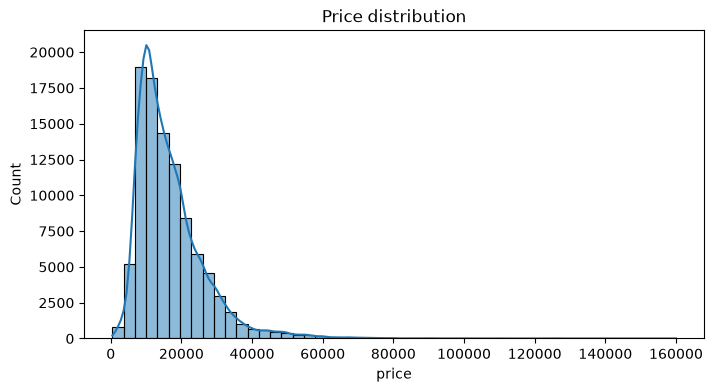

Skew: 2.3624777751761386


In [31]:

plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price distribution')
plt.show()
print("Skew:", df['price'].skew())

In [32]:
# The price distribution is strongly right-skewed (skewness ≈ 2.36).
# Most vehicles are concentrated in the lower-to-mid price range,
# while a small number of expensive vehicles create a long right tail.

In [33]:
df['price_log'] = np.log1p(df['price'])

In [34]:
import os

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/cars_clean.csv", index=False)
print("Saved cleaned data:", df.shape)

Saved cleaned data: (97675, 12)


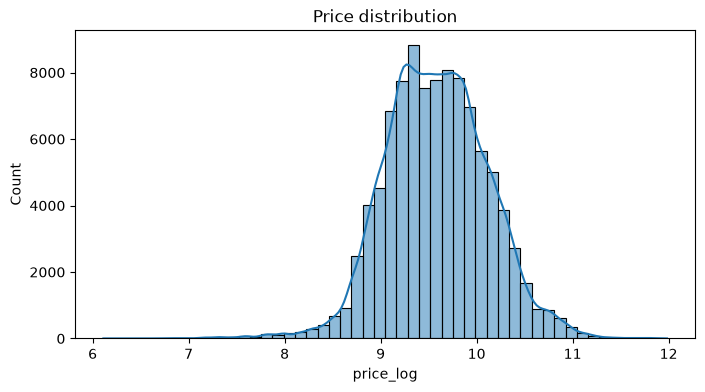

Skew: -0.0759713220696199


In [35]:
plt.figure(figsize=(8,4))
sns.histplot(df['price_log'], bins=50, kde=True)
plt.title('Price distribution')
plt.show()
print("Skew:", df['price_log'].skew())

In [36]:
def iqr_outlier_summary(df, cols):
    rows = []
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        count = ((df[col] < lower) | (df[col] > upper)).sum()
        rows.append({
            'column': col,
            'skew': round(df[col].skew(), 2),
            'lower_fence': round(lower, 1),
            'upper_fence': round(upper, 1),
            'outliers': count,
            'pct': round(count/len(df)*100, 2)
        })
    return pd.DataFrame(rows)

iqr_outlier_summary(df, ['price_log', 'mileage', 'tax', 'mpg', 'engineSize', 'age'])

,column,skew,lower_fence,upper_fence,outliers,pct
0,price_log,-0.08,8.1,11.0,1031,1.06
1,mileage,1.78,-29542.5,69725.5,3837,3.93
2,tax,0.04,95.0,175.0,28581,29.26
3,mpg,9.03,23.6,86.4,896,0.92
4,engineSize,1.41,-0.0,3.2,648,0.66
5,age,1.81,2.5,14.5,1732,1.77


In [37]:
df['mpg'].sort_values(ascending=False).head(15)

83808    470.8
85926    470.8
84552    470.8
84614    470.8
83483    470.8
86113    470.8
84612    470.8
83584    470.8
86138    470.8
83528    470.8
83358    470.8
86358    470.8
82604    470.8
82914    470.8
83240    470.8
Name: mpg, dtype: float64

In [38]:
(df['mpg'] > 100).sum()

np.int64(568)

In [39]:
df[df['mpg'] == 470.8][['model', 'fuelType', 'engineSize', 'price']].head(10)

,model,fuelType,engineSize,price
77770,i3,Other,0.6,17100
78359,i3,Hybrid,0.6,19998
78516,i3,Hybrid,0.6,19998
78518,i3,Hybrid,0.6,21898
79604,i3,Hybrid,0.6,19980
80090,i3,Hybrid,0.6,19490
81015,i3,Hybrid,0.6,16482
81366,i3,Hybrid,0.6,14285
81651,i3,Hybrid,0.6,18500
81838,i3,Hybrid,0.6,19495


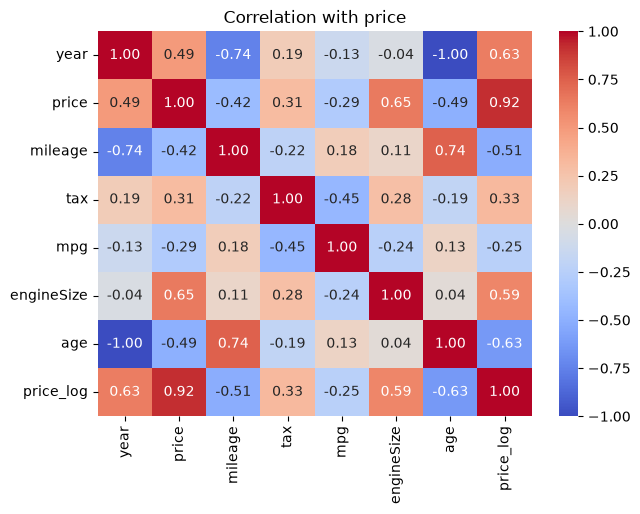

In [40]:
# Correlation heatmap — numeric features only
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(7,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with price')
plt.show()

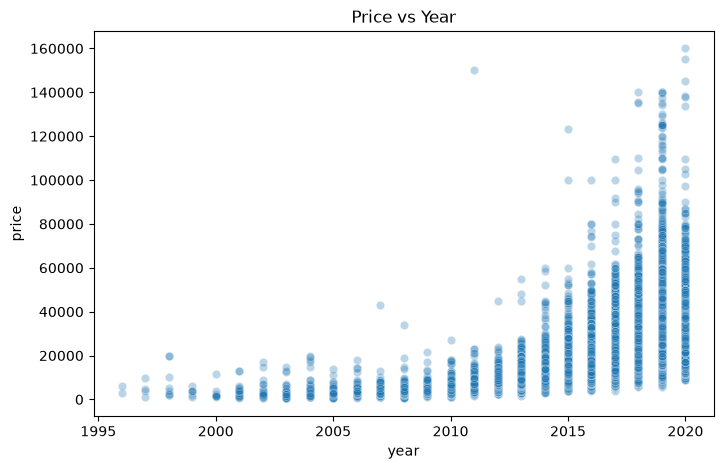

In [41]:
# Price vs Year (age) — expect a curve, not a straight line
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='year', y='price', alpha=0.3)
plt.title('Price vs Year')
plt.show()

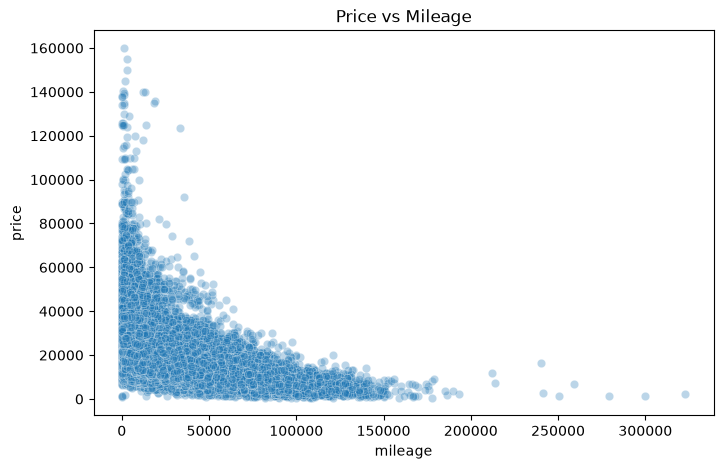

In [42]:
#  Price vs Mileage
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='mileage', y='price', alpha=0.3)
plt.title('Price vs Mileage')
plt.show()

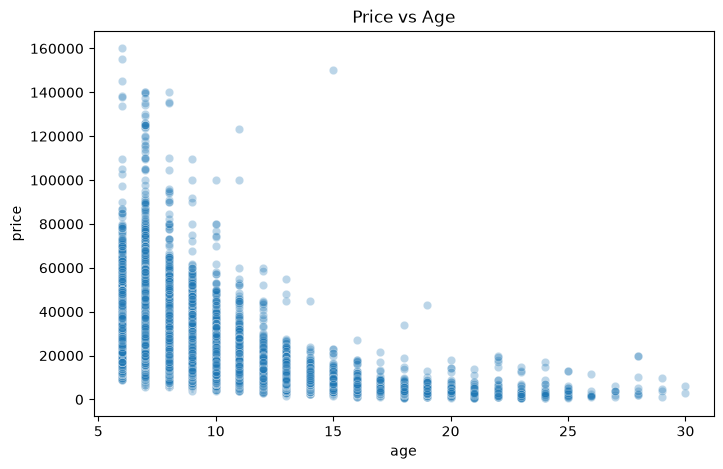

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='age', y='price', alpha=0.3)
plt.title('Price vs Age')
plt.show()

In [44]:
# Price generally decreases as vehicle age increases. However, newer
# vehicles show a much wider range of prices, indicating that factors
# such as make, model, mileage, and engine size also strongly influence
# vehicle price.